# KG-Commit V4 --- Additional Experiments & Visualizations

**Apache Groovy, ApacheJIT, 8,059 labelled commits.** Beyond the accuracy tables,
online-evaluation streams, and scalability plots, this notebook presents a set of
visualizations that expose *why* the multimodal, semantic knowledge graph works ---
the kind of insight-driven figures a Q1 reviewer looks for.

Everything is produced from **cached artifacts** (`outputs/*.pkl/.npy/.csv`) and
**read-only** queries against the built graph (Term risk/kind, Intent typing,
grounding) --- **no KG rebuild**. The figure code lives in
`scalability/make_insight_figures.py`; here we render each figure inline with its
takeaway.

**Contents**
1. Multimodal complementarity --- why fusion beats any single signal
2. The commit KG-embedding, projected
3. Interpretable defect-typing I: bug rate by change-intent
4. Interpretable defect-typing II: learned term risk by semantic type
5. Calibration / reliability of the deployed predictor
6. Concept drift --- signals tracking the moving bug rate
7. The structural signature of a buggy change
8. CSTG internal-layer ablation --- is the graph-of-words math the win, or the layer?
9. CSTG as a graph --- the five inference methods over its separated layers
   (9a: full 7-metric tables; 9b: PPR online streams; 9c: deployed fusion F+G
   streams with the G trend; 9d: graph fusion F across layers with F/G/F+G on
   full CSTG, Macro-F1 & G-Mean)


In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "scalability").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scalability"))
import make_insight_figures as vis
from IPython.display import Image, display
import pandas as pd
FIG = ROOT / "docs" / "figures" / "v4" / "insight"
FIG_SCAL = ROOT / "docs" / "figures" / "v4" / "scalability"
SCAL_OUT = ROOT / "outputs" / "scalability"
S = vis._streams()   # cached per-commit feature streams (no DB)
print("streams:", {k: (getattr(v, 'shape', v) if k not in ('N','W') else v) for k,v in list(S.items())[:6]})
def show(stem): display(Image(str(FIG / f"{stem}.png")))
def show_scal(stem): display(Image(str(FIG_SCAL / f"{stem}.png")))


streams: {'y': (8059,), 'N': 8059, 'W': 2417, 'Xms': (8059, 12), 'Xp': (8059, 5), 'Xh': (8059, 262144)}


## 1. Multimodal complementarity --- the core justification for fusion

Each modality (JIT metrics **M**, relational priors **R**, AST change-tokens
**T**, PPR **P**, and the CSTG semantic prior/typing **G**) is reduced to a single
risk score. **Left:** every modality is individually predictive (AUC well above
0.5). **Right:** the scores are only weakly correlated across families --- structural
(T), relational (R/P), and semantic (G) capture largely *independent* evidence. High
individual signal + low cross-correlation is exactly the condition under which fusion
outperforms any single channel, which is what the deployed F+G model exploits.

  fig_modality_complementarity


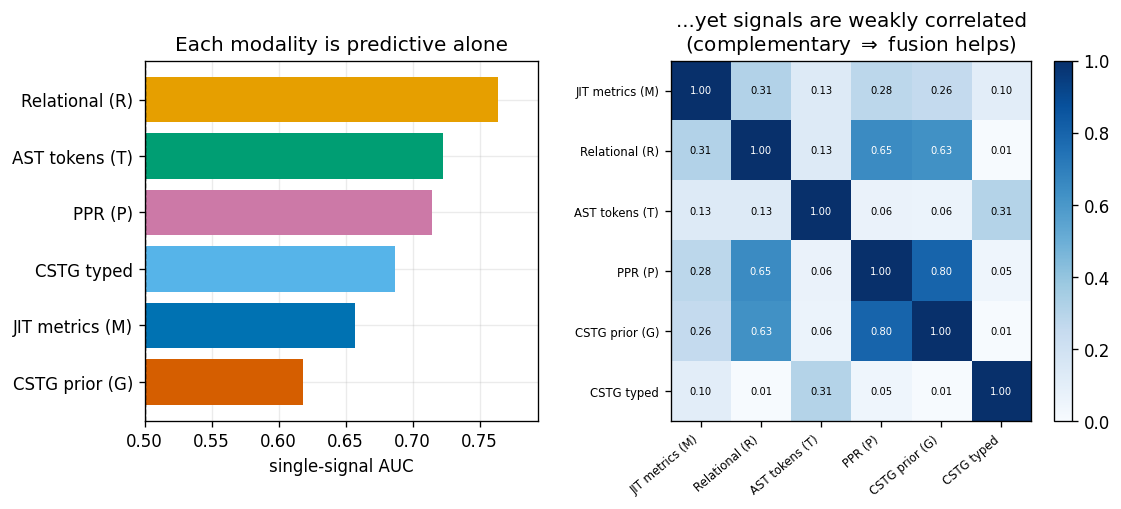

In [2]:
vis.fig_modality_complementarity(S)
show('fig_modality_complementarity')

## 2. The commit knowledge-graph embedding, projected

A 2-D PCA projection of the DistMult KG-embedding of every commit, coloured by
label. Buggy commits are not linearly separable --- defect prediction is genuinely
hard --- but they concentrate in identifiable regions of the learned geometry, which
is the signal the graph-native embedding methods (DW, KGE) contribute to the fusion.

  fig_commit_embedding


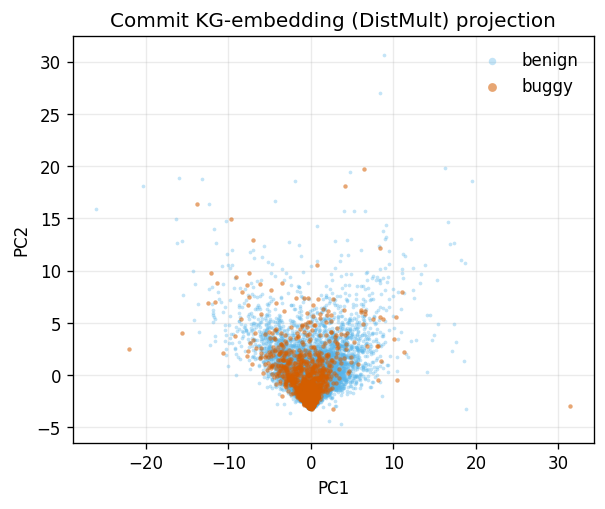

In [3]:
vis.fig_commit_embedding(S)
show('fig_commit_embedding')

## 3. Interpretable defect-typing I --- bug rate by change-intent

The CSTG types each commit's *intent* (fix / feat / refactor / perf / ...).
Plotting the empirical bug rate per intent gives an immediately interpretable risk
ordering: **perf** and **fix** changes are the most defect-prone (fixes that
introduce new bugs --- the classic SZZ phenomenon), while **docs** and **revert**
changes are safest. This is a human-auditable explanation the graph provides for
free.

  fig_intent_bugrate


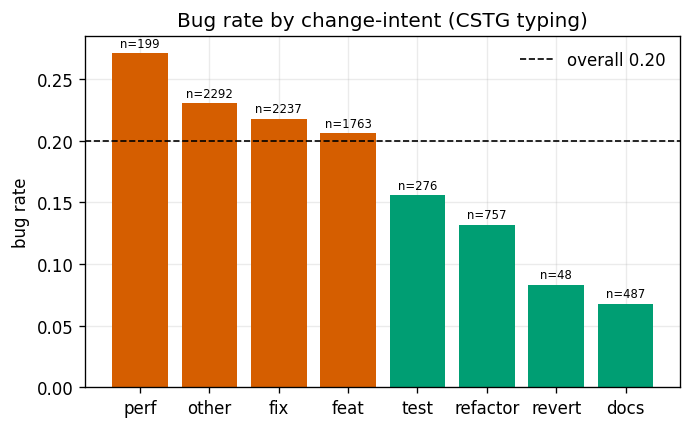

In [4]:
vis.fig_intent_bugrate()
show('fig_intent_bugrate')

## 4. Interpretable defect-typing II --- learned term risk by semantic type

Every CSTG **Term** carries a learned, past-propagated bug-risk. **Left:**
mean risk by lexicon type (code / nl / error / bug / action). **Right:** the
highest-risk individual terms among the defect-relevant lexicons. Because these risks
are attached to graph nodes and grounded to AST locations, the model's semantic
evidence is inspectable rather than a black box.

  fig_defect_typing


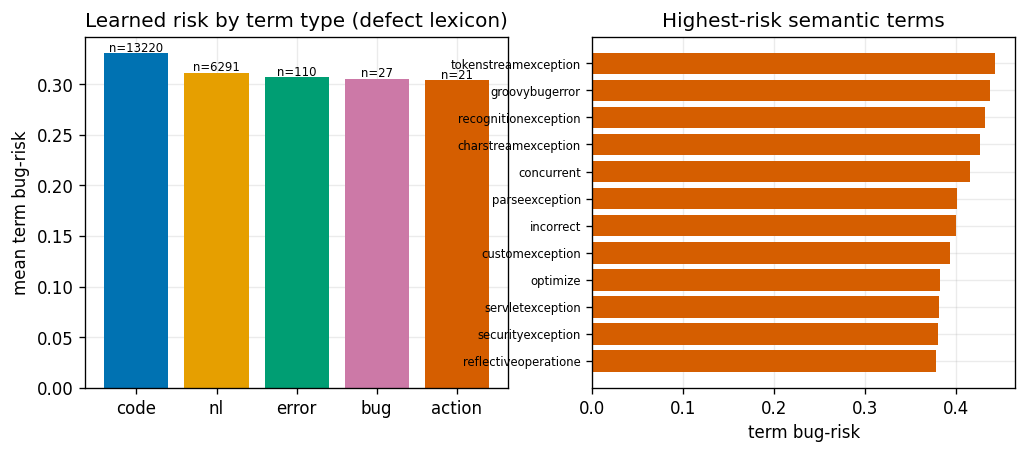

In [5]:
vis.fig_defect_typing()
show('fig_defect_typing')

## 5. Calibration / reliability of the deployed predictor

A reliability curve: predicted bug probability vs.\ the observed bug rate in
each probability bin (bin counts annotated). A well-behaved, monotonic curve means
the scores are usable as *probabilities* --- essential for cost-aware triage where a
team acts on the highest-risk commits, not just a ranking.

  fig_calibration


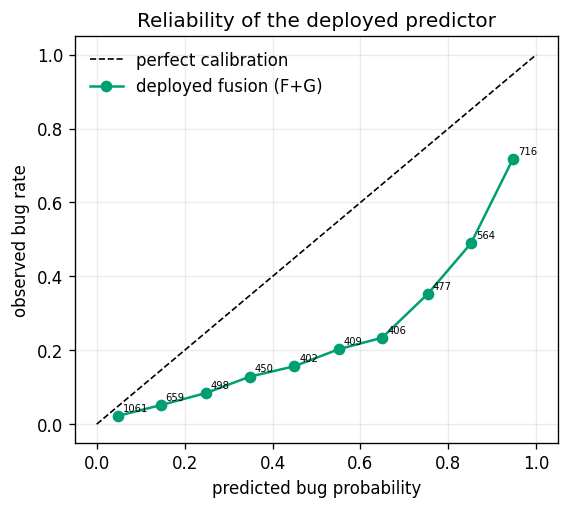

In [6]:
vis.fig_calibration()
show('fig_calibration')

## 6. Concept drift --- signals track the moving bug rate

The Groovy bug rate drifts substantially over 2003--2019. Overlaying the
rolling AUC of two complementary signals (the CSTG semantic prior and the PPR graph
score) on the rolling bug rate shows that the online, prequential design keeps the
signals informative *through* the drift --- the reason a time-aware protocol is
essential and a static split would mislead.

  fig_drift_signal


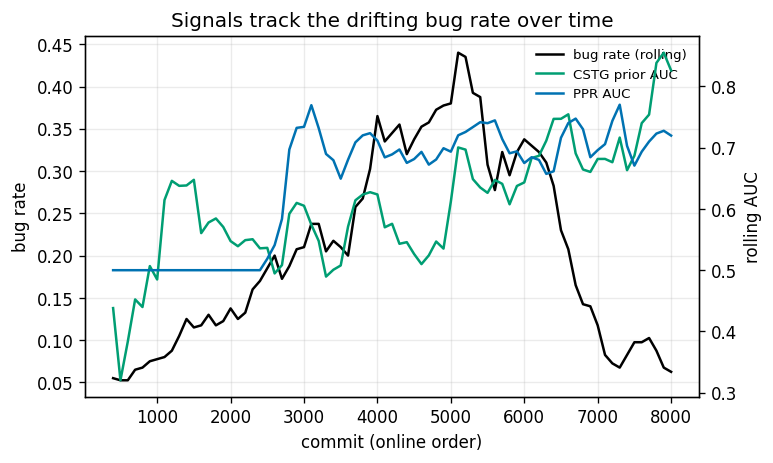

In [7]:
vis.fig_drift_signal(S)
show('fig_drift_signal')

## 7. The structural signature of a buggy change

Decomposing each commit's AST change by node group (declaration / statement /
expression / literal / identifier-leaf) and comparing buggy vs.\ benign commits:
buggy changes touch proportionally more **expression**-level nodes --- fine-grained
logic edits --- than benign ones. This is the interpretable, structural counterpart
to the raw "buggy commits are larger" signal.

  fig_astgroup_risk


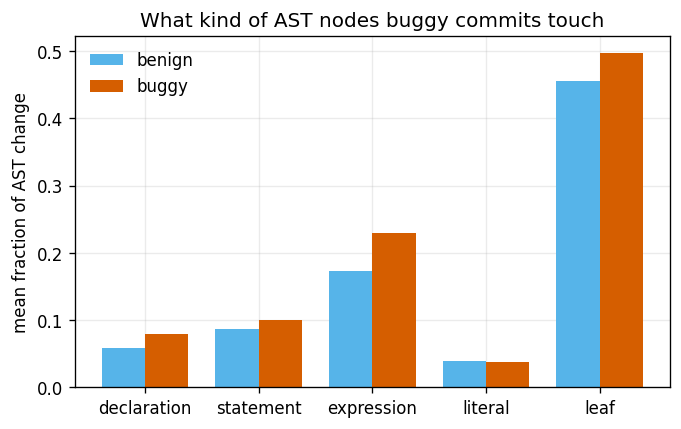

In [8]:
vis.fig_astgroup_risk()
show('fig_astgroup_risk')

## 8. CSTG internal-layer ablation --- is the graph-of-words math the win, or the layer?

The paper is deliberately honest that graph-of-words (TW-IDF) weighting *alone*
does not beat plain TF-IDF under a linear learner in one batch window (right
panel below). This cell adds the row that comparison was missing: a
**same-learner, matched-vocabulary** TF-IDF baseline under Random Forest (left
panel), computed DB-free from the cached fitted CSTG bundle
(`scalability/collect_cstg_ablation.py`, no re-parse, no Neo4j).

**Reading it:** under the matched RF learner, plain TF-IDF (.818), TW-IDF (.817)
and the full CSTG (.821) are statistically close on this controlled batch split
--- only stacking JIT metrics on top (.827) clears the published external
baseline (.813, dashed). The CSTG's real advantage is **not** this batch
comparison; it is the fully online protocol (Table `tab:cstgonline` in the
paper), where CSTG-alone reaches ROC 0.821 / PR-AUC 0.588 because it can exploit
relational propagation and recency across the commit stream --- something no
static TF-IDF baseline, matched or not, can do. We report both honestly rather
than only the version that looks better.

test bug-rate=0.075  published baseline ROC=0.813


,ROC,PR,F1,Popt,ACC20
Component,,,,,
Plain TF-IDF (bag-of-words) [RF],0.818,0.352,0.375,0.821,0.648
TW-IDF (graph-of-words) [RF],0.817,0.296,0.391,0.833,0.648
Full CSTG (+prior+typed) [RF],0.821,0.302,0.402,0.835,0.659
JIT + full CSTG [RF],0.827,0.314,0.390,0.840,0.670
(a) Plain TF-IDF (bag-of-words) [LR],0.769,0.268,0.223,0.812,0.615
(b) TW-IDF (graph-of-words) [LR],0.746,0.171,0.216,0.803,0.582
(c) NPMI-propagated prior alone,0.723,0.149,0.000,0.785,0.571
(d) TW-IDF + prior [LR],0.752,0.188,0.211,0.805,0.593
(e) Full CSTG (+typed) [LR],0.767,0.176,0.238,0.810,0.604


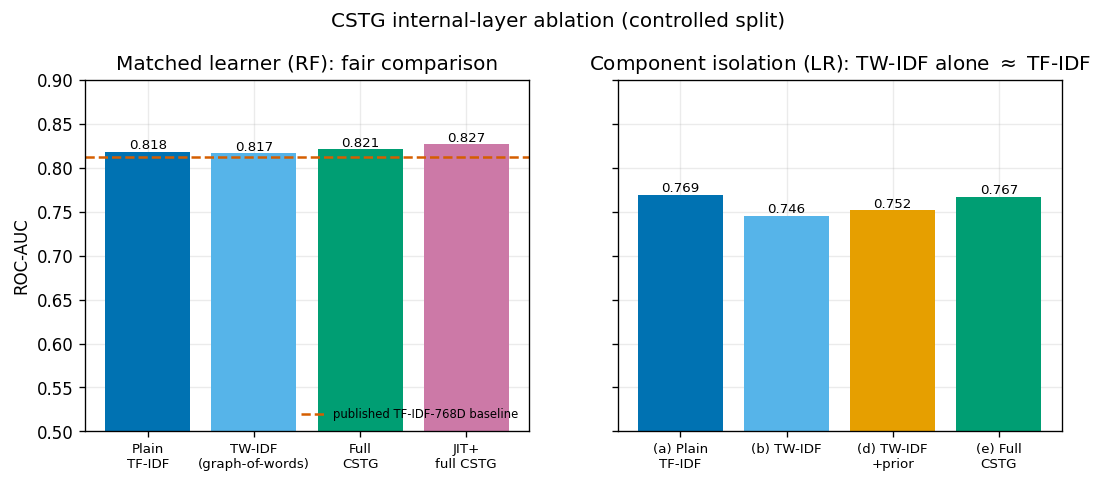

In [9]:
abl = json.load(open(SCAL_OUT / "cstg_ablation.json"))
rows = []
for k, v in abl["components"].items():
    rows.append(dict(Component=v["pretty"], ROC=round(v["ROC"],3), PR=round(v["PR"],3),
                     F1=round(v["F1"],3), Popt=round(v["Popt"],3), ACC20=round(v["ACC20"],3)))
df = pd.DataFrame(rows).set_index("Component")
print(f"test bug-rate={abl['_meta']['test_bug_rate']:.3f}  "
      f"published baseline ROC={abl['_meta']['published_baseline_RF']['ROC']}")
display(df)
show_scal("fig_cstg_ablation")

## 9. CSTG as a GRAPH --- the five inference methods over its separated layers

Section 8 treats the CSTG as a *feature matrix*. But it is also a *graph*
(Commit→Term mentions, Term↔Term NPMI edges, typed terms), so here we run the
five final graph-inference methods (RN, PPR, LP, DW, KGE) over it **fully online**,
one column per separated CSTG layer, and compare to the graph-independent **G**
feature classifier (`scalability/cstg_online_graph_ablation.py`, all read-only /
cached). This is the graph-native counterpart to Section 8.

**What it shows:** PPR is the best graph method, and it is the plain *unweighted*
term hubs that help it most (AUC 0.728→0.757); TW-IDF weighting and the
higher-order structure (COOCCURS NPMI edges, term typing) do not help the graph
methods --- an honest null result for those mechanisms at prediction time; and the
**G feature classifier beats every graph method on the same CSTG signal**
(AUC 0.789, dashed line above all curves). That is precisely why the deployed model
fuses G explicitly (F+G) rather than routing CSTG through the graph walks alone.

=== AUC (online) ===


,Core,+MENTIONS (unweighted),+MENTIONS (TW-IDF),+COOCCURS (NPMI),Full CSTG (+typed)
Method,,,,,
RN,0.696,0.683,0.674,0.674,0.674
PPR,0.728,0.757,0.743,0.744,0.744
LP,0.687,0.674,0.679,0.679,0.679
DW,0.576,0.657,0.642,0.642,0.642
KGE,0.629,0.655,0.655,0.655,0.660
G (feature clf.),0.789,0.789,0.789,0.789,0.789


=== MCC (online) ===


,Core,+MENTIONS (unweighted),+MENTIONS (TW-IDF),+COOCCURS (NPMI),Full CSTG (+typed)
Method,,,,,
RN,0.131,0.000,0.017,0.017,0.017
PPR,0.280,0.300,0.291,0.290,0.290
LP,0.144,0.025,0.041,0.041,0.041
DW,0.098,0.209,0.187,0.187,0.187
KGE,0.170,0.199,0.199,0.199,0.199
G (feature clf.),0.320,0.320,0.320,0.320,0.320


=== Buggy_F1 (online) ===


,Core,+MENTIONS (unweighted),+MENTIONS (TW-IDF),+COOCCURS (NPMI),Full CSTG (+typed)
Method,,,,,
RN,0.493,0.470,0.455,0.455,0.455
PPR,0.499,0.526,0.516,0.514,0.514
LP,0.459,0.453,0.475,0.475,0.475
DW,0.396,0.449,0.445,0.445,0.445
KGE,0.439,0.453,0.453,0.453,0.453
G (feature clf.),0.550,0.550,0.550,0.550,0.550


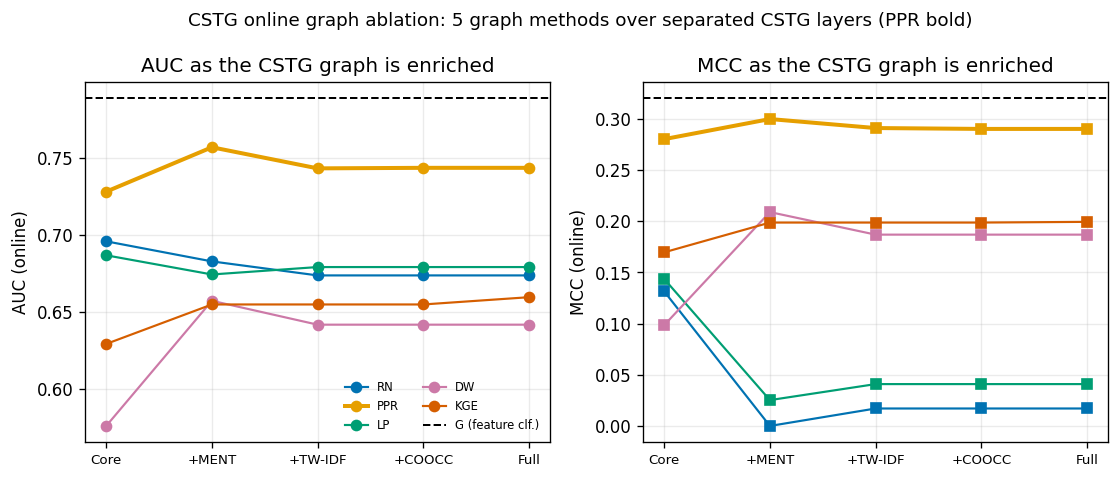

In [10]:
ga = json.load(open(SCAL_OUT / "cstg_graph_ablation.json"))
variants = ga["_meta"]["variants"]; methods = ga["_meta"]["methods"]
vname = ga["_meta"]["variant_names"]
# AUC and MCC tables (method x variant), with the G reference row appended
for metric in ("AUC", "MCC", "Buggy_F1"):
    rows = []
    for m in methods:
        rows.append(dict(Method=m, **{vname[v]: round(ga[v]["methods"][m][metric],3) for v in variants}))
    if "G_channel" in ga:
        rows.append(dict(Method="G (feature clf.)", **{vname[v]: round(ga["G_channel"][metric],3) for v in variants}))
    print(f"=== {metric} (online) ===")
    display(pd.DataFrame(rows).set_index("Method"))
show_scal("fig_cstg_graph_ablation")

### 9a. All seven metrics, per CSTG layer

The full seven-metric online-evaluation suite (Precision, Recall, Buggy-F1,
Macro-F1, G-Mean, AUC, MCC) for every method on each separated CSTG hub-graph
layer and the full CSTG, with the graph-independent **G** feature classifier as a
reference block. This is the complete version of the summary above.

In [11]:
M7 = ["Precision","Recall","Buggy_F1","Macro_F1","G_Mean","AUC","MCC"]
for v in variants:
    rows = []
    for m in methods:
        rows.append(dict(Method=m, **{mt: round(ga[v]["methods"][m][mt],3) for mt in M7}))
    if "G_channel" in ga:
        rows.append(dict(Method="G (feature clf.)", **{mt: round(ga["G_channel"][mt],3) for mt in M7}))
    print(f"=== {vname[v]} (online, all 7 metrics) ===")
    display(pd.DataFrame(rows).set_index("Method"))

=== Core (online, all 7 metrics) ===


,Precision,Recall,Buggy_F1,Macro_F1,G_Mean,AUC,MCC
Method,,,,,,,
RN,0.373,0.730,0.493,0.603,0.662,0.696,0.131
PPR,0.371,0.761,0.499,0.600,0.665,0.728,0.280
LP,0.318,0.820,0.459,0.518,0.594,0.687,0.144
DW,0.264,0.792,0.396,0.407,0.473,0.576,0.098
KGE,0.299,0.827,0.439,0.479,0.553,0.629,0.170
G (feature clf.),0.430,0.763,0.550,0.659,0.716,0.789,0.320


=== +MENTIONS (unweighted) (online, all 7 metrics) ===


,Precision,Recall,Buggy_F1,Macro_F1,G_Mean,AUC,MCC
Method,,,,,,,
RN,0.323,0.863,0.470,0.519,0.597,0.683,0.000
PPR,0.405,0.749,0.526,0.636,0.694,0.757,0.300
LP,0.307,0.863,0.453,0.487,0.564,0.674,0.025
DW,0.328,0.710,0.449,0.550,0.612,0.657,0.209
KGE,0.307,0.864,0.453,0.487,0.563,0.655,0.199
G (feature clf.),0.430,0.763,0.550,0.659,0.716,0.789,0.320


=== +MENTIONS (TW-IDF) (online, all 7 metrics) ===


,Precision,Recall,Buggy_F1,Macro_F1,G_Mean,AUC,MCC
Method,,,,,,,
RN,0.314,0.823,0.455,0.510,0.586,0.674,0.017
PPR,0.385,0.785,0.516,0.615,0.682,0.743,0.291
LP,0.327,0.868,0.475,0.524,0.604,0.679,0.041
DW,0.319,0.738,0.445,0.533,0.600,0.642,0.187
KGE,0.307,0.864,0.453,0.487,0.563,0.655,0.199
G (feature clf.),0.430,0.763,0.550,0.659,0.716,0.789,0.320


=== +COOCCURS (NPMI) (online, all 7 metrics) ===


,Precision,Recall,Buggy_F1,Macro_F1,G_Mean,AUC,MCC
Method,,,,,,,
RN,0.314,0.823,0.455,0.510,0.586,0.674,0.017
PPR,0.387,0.765,0.514,0.617,0.681,0.744,0.290
LP,0.327,0.868,0.475,0.524,0.604,0.679,0.041
DW,0.319,0.738,0.445,0.533,0.600,0.642,0.187
KGE,0.307,0.864,0.453,0.487,0.563,0.655,0.199
G (feature clf.),0.430,0.763,0.550,0.659,0.716,0.789,0.320


=== Full CSTG (+typed) (online, all 7 metrics) ===


,Precision,Recall,Buggy_F1,Macro_F1,G_Mean,AUC,MCC
Method,,,,,,,
RN,0.314,0.823,0.455,0.510,0.586,0.674,0.017
PPR,0.387,0.765,0.514,0.617,0.681,0.744,0.290
LP,0.327,0.868,0.475,0.524,0.604,0.679,0.041
DW,0.319,0.738,0.445,0.533,0.600,0.642,0.187
KGE,0.306,0.869,0.453,0.484,0.560,0.660,0.199
G (feature clf.),0.430,0.763,0.550,0.659,0.716,0.789,0.320


### 9b. PPR online-evaluation stream across CSTG layers (Macro-F1 & G-Mean)

The prequential *trajectory* of the best graph method (PPR) as commits arrive, one
line per CSTG hub-graph layer. Each point is a metric over a trailing rolling
window (the same `metric_traj` used for the paper's other stream figures), so the
curves show *when* over the 2003--2019 stream each CSTG layer helps or hurts PPR
--- not just the end-of-stream scalar. We plot the two class-balanced metrics
**Macro-F1** and **G-Mean**. The layers track together for most of the stream
(the plain term hubs carry the signal); the shared decline into the low-defect
2018--2019 tail is the project-wide concept drift, not a CSTG effect.

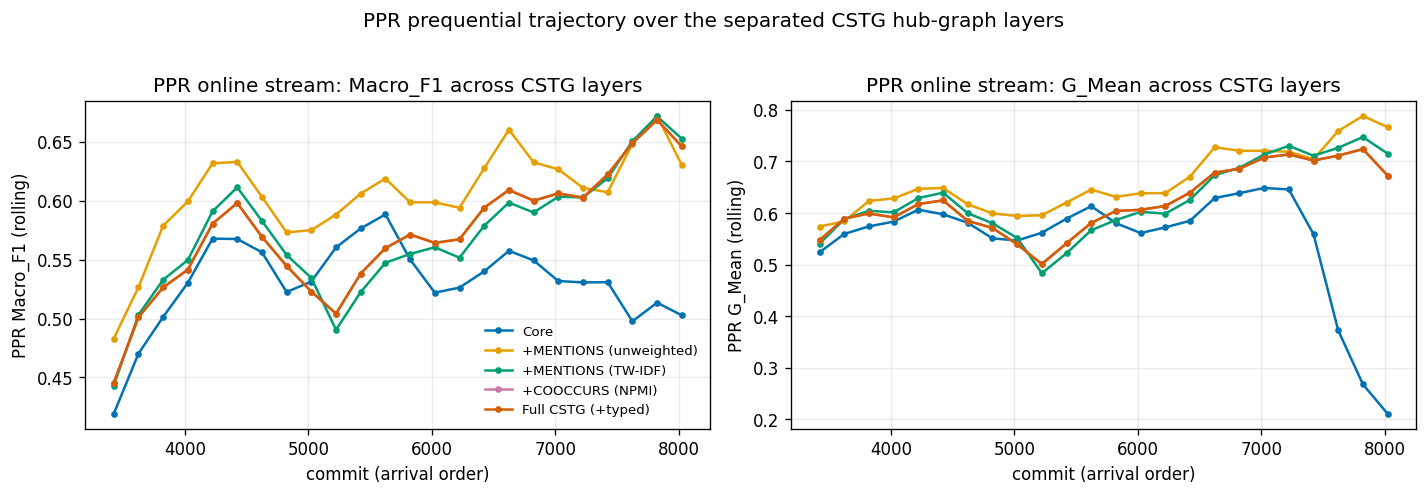

In [12]:
import matplotlib.pyplot as plt
OI = ["#0072B2","#E69F00","#009E73","#CC79A7","#D55E00","#56B4E9","#000000"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["Macro_F1", "G_Mean"]):
    for k, v in enumerate(variants):
        tr = ga[v].get("ppr_traj")
        if not tr: continue
        ax.plot(tr["idx"], tr[metric], marker="o", ms=3, color=OI[k], label=vname[v])
    ax.set_xlabel("commit (arrival order)"); ax.set_ylabel(f"PPR {metric} (rolling)")
    ax.set_title(f"PPR online stream: {metric} across CSTG layers")
    ax.grid(alpha=0.25)
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("PPR prequential trajectory over the separated CSTG hub-graph layers", y=1.02)
fig.tight_layout()
# save + display via Image (the kernel's Agg backend does not render plt.show())
_out = FIG_SCAL / "fig_cstg_ppr_stream.png"
fig.savefig(_out, dpi=120, bbox_inches="tight"); fig.savefig(_out.with_suffix(".pdf"), bbox_inches="tight")
plt.close(fig)
display(Image(str(_out)))

### 9c. Deployed fusion stream across CSTG layers (Macro-F1 & G-Mean), with the G trend

The plot that matches the *deployed* model: for each CSTG hub-graph layer we build
the deployed fusion **F+G = RN+PPR+CSTG** --- the two graph methods on that layer's
graph, stacked with the CSTG feature channel by the same prequential logistic
regression used in `run_final_fusion.py` --- and plot its rolling **Macro-F1** and
**G-Mean** over the commit stream. The dashed black **G** trend is the CSTG feature
classifier evaluated online on its own, the reference the graph fusion is measured
against. This shows, over the whole 2003--2019 stream, how much the CSTG graph
layer adds *on top of* the graph methods once G is fused in --- the deployment view,
not just PPR in isolation (9b).

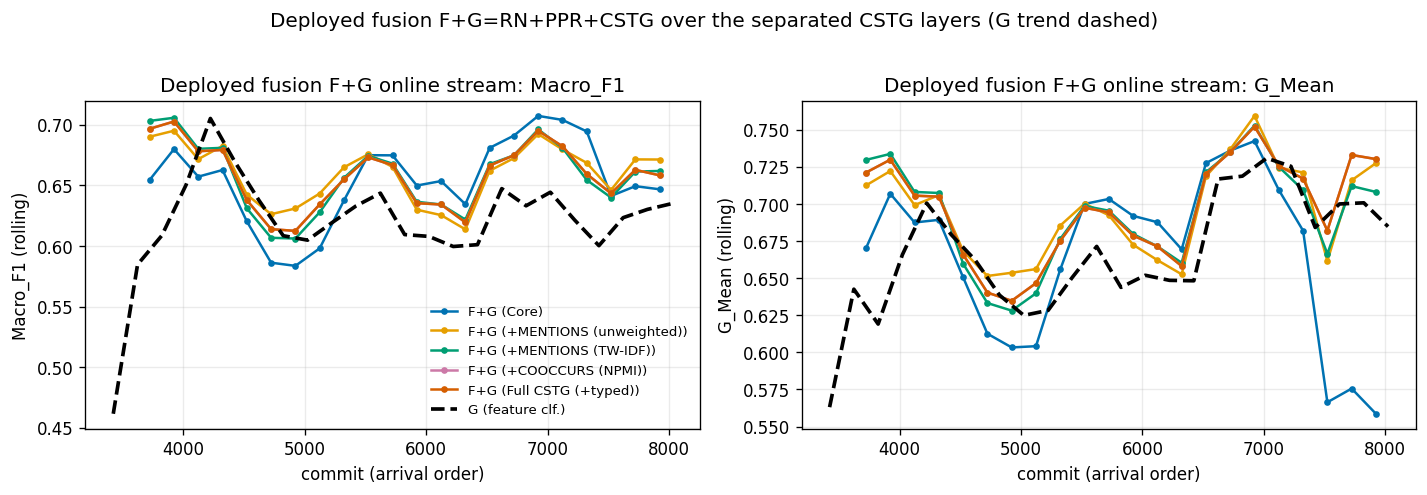

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["Macro_F1", "G_Mean"]):
    for k, v in enumerate(variants):
        tr = ga[v].get("fusion_traj")
        if not tr: continue
        ax.plot(tr["idx"], tr[metric], marker="o", ms=3, color=OI[k], label=f"F+G ({vname[v]})")
    gt = ga.get("G_traj")
    if gt:
        ax.plot(gt["idx"], gt[metric], color="#000000", lw=2.2, ls="--", label="G (feature clf.)")
    ax.set_xlabel("commit (arrival order)"); ax.set_ylabel(f"{metric} (rolling)")
    ax.set_title(f"Deployed fusion F+G online stream: {metric}")
    ax.grid(alpha=0.25)
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Deployed fusion F+G=RN+PPR+CSTG over the separated CSTG layers "
             "(G trend dashed)", y=1.02)
fig.tight_layout()
_out = FIG_SCAL / "fig_cstg_fusion_stream.png"
fig.savefig(_out, dpi=120, bbox_inches="tight"); fig.savefig(_out.with_suffix(".pdf"), bbox_inches="tight")
plt.close(fig)
display(Image(str(_out)))

### 9d. Graph fusion F across CSTG layers, with F / G / F+G on full CSTG

The requested view. The coloured lines are the graph fusion **F = RN+PPR** on each
*separated* CSTG hub-graph layer (Core, +MENTIONS, +TW-IDF, +COOCCURS) --- how the
graph-only fusion behaves as the CSTG graph is enriched. Against them we overlay
three reference trends, all on the **full CSTG** layer: **F** (graph fusion),
**G** (the CSTG feature classifier alone), and **F+G** (the deployed model). This
isolates two questions on one axis: (i) does enriching the CSTG graph change the
graph fusion F (the coloured lines cluster → no), and (ii) what does the semantic
channel add --- F+G (full) sits above both F (full) and G (full), the deployment
justification. Metrics are the two class-balanced ones, Macro-F1 and G-Mean,
rolling over the commit stream.

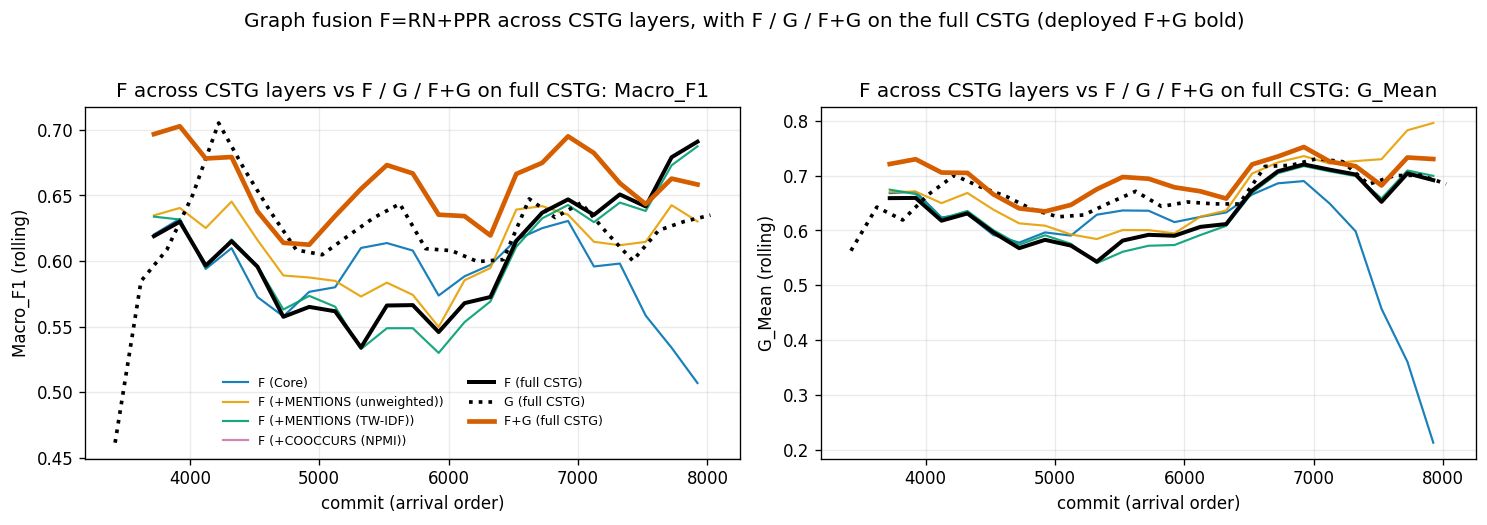

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
layer_variants = [v for v in variants if v != "full"]   # separated layers
for ax, metric in zip(axes, ["Macro_F1", "G_Mean"]):
    # F on each separated CSTG layer (thin coloured lines)
    for k, v in enumerate(layer_variants):
        tr = ga[v].get("F_traj")
        if not tr: continue
        ax.plot(tr["idx"], tr[metric], color=OI[k], lw=1.3, alpha=0.9,
                label=f"F ({vname[v]})")
    # three reference trends on FULL CSTG
    fF = ga["full"].get("F_traj")
    if fF:
        ax.plot(fF["idx"], fF[metric], color="#000000", lw=2.4, ls="-",
                label="F (full CSTG)")
    gt = ga.get("G_traj")
    if gt:
        ax.plot(gt["idx"], gt[metric], color="#000000", lw=2.2, ls=":",
                label="G (full CSTG)")
    fg = ga["full"].get("fusion_traj")
    if fg:
        ax.plot(fg["idx"], fg[metric], color="#D55E00", lw=2.8, ls="-",
                label="F+G (full CSTG)")
    ax.set_xlabel("commit (arrival order)"); ax.set_ylabel(f"{metric} (rolling)")
    ax.set_title(f"F across CSTG layers vs F / G / F+G on full CSTG: {metric}")
    ax.grid(alpha=0.25)
axes[0].legend(frameon=False, fontsize=7.5, ncol=2)
fig.suptitle("Graph fusion F=RN+PPR across CSTG layers, with F / G / F+G on the "
             "full CSTG (deployed F+G bold)", y=1.03)
fig.tight_layout()
_out = FIG_SCAL / "fig_cstg_F_layers_stream.png"
fig.savefig(_out, dpi=120, bbox_inches="tight"); fig.savefig(_out.with_suffix(".pdf"), bbox_inches="tight")
plt.close(fig)
display(Image(str(_out)))

## Takeaways

* **Fusion is principled, not incidental.** The modalities are individually
  predictive yet weakly correlated across the structural / relational / semantic
  families --- so combining them recovers independent evidence (Fig. 1). This is the
  visual core of the paper's multimodal argument.
* **The graph is interpretable.** Change-intent and term-level risk give
  human-auditable, grounded explanations for a commit's predicted risk (Figs. 3--4),
  a differentiator over metric-only JIT models.
* **The predictor is deployable.** It is reasonably calibrated (Fig. 5) and its
  signals survive the pronounced concept drift under the online protocol (Fig. 6).
* **Risk has a structural signature.** Buggy commits concentrate in identifiable
  embedding regions (Fig. 2) and skew toward expression-level AST edits (Fig. 7).
* **The CSTG's win is the layer, not the centrality math.** Under a matched
  learner, plain TF-IDF and the full CSTG are statistically close on a static
  batch split (Fig. 8) --- the layer's real advantage only shows up online, where
  its relational propagation and recency mechanisms have a commit stream to
  exploit. We report this honestly rather than only the favourable framing.
* **CSTG signal is best used as a feature channel, not graph walks.** Running the
  five graph methods over the CSTG's own graph (Fig. 9), PPR leads (helped by the
  plain term hubs, not the weighting or higher-order structure), but the G feature
  classifier beats every graph method --- validating the deployed F+G design, where
  G enters as an explicit fused channel.
